In [2]:
import torch
from torch.distributions import MultivariateNormal, Categorical, MixtureSameFamily
import zuko
import matplotlib.pyplot as plt
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam


/root/phd/GW_seperation_analysis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import sys
# !{sys.executable} -m pip install zuko


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# we start with a 4 d problem, get 2, 2d gaussians,
# Use normalizing flows from U[0,1] distr to the gaussian, these are the quantiles
d_1 = 2
d_2 = 2
flow_1 = zuko.flows.spline.NSF(
    features=d_1,  #dim of the output
    transforms=8,
)
dist_1 = flow_1()
T_1    = dist_1.transform

flow_2 = zuko.flows.spline.NSF(
    features=d_2,  #dim of the output
    transforms=8,
)
dist_2 = flow_2()
T_2    = dist_2.transform

def sampleGaussianBase(params,N):
    # Covariance matrix (identity) #correlated
    d           = params["d"]
    sqrtSigma   = torch.linalg.cholesky(params["Sigma"])
    chi2        = torch.distributions.Chi2(df=d)
    chi_samples = torch.sqrt(chi2.sample((N,)))

    Z           = torch.randn(N, d)
    U_samples   = Z / torch.norm(Z, dim=1, keepdim=True)
    res         = chi_samples*(sqrtSigma @ U_samples.T)
    return res

def InvTransport(params,res,indx):
    Sigma   = params["Sigma"]
    S       = torch.linalg.cholesky(Sigma[indx,indx])
    dist    = torch.distributions.Normal(loc=0, scale=1)
    Transf  = S.T @ res[indx,:]
    blocks  = []
    for i in range(indx.stop - indx.start):
        blocks.append(dist.cdf(Transf[i,:]).unsqueeze(0))
    Z = torch.cat(blocks, dim=0)
    return Z.T

def sampleVectorCopula(params,N):
    res = sampleGaussianBase(params,N)
    Z_1 = InvTransport(params, res, slice(0, 2))
    Z_2 = InvTransport(params, res, slice(2, 4))
    return Z_1,Z_2

def sampleVectorCopulaModel(params,N):
    Z_1,Z_2 = sampleVectorCopula(params,N)
    dist    = torch.distributions.Normal(loc=0, scale=1)
    sample_1 = T_1(dist.cdf(Z_1)) #can be used because they are independent
    sample_2 = T_2(dist.cdf(Z_2))
    return torch.cat([sample_1,sample_2], dim=1).T

def logProbCopula(params,theta):
    dist            = torch.distributions.Normal(loc=0, scale=1)
    Sigma           = params['Sigma']
    _, logabsdet    = torch.linalg.slogdet(Sigma)
    SigmaInv        = torch.linalg.inv(Sigma)
    PhiInv          = dist.icdf(theta)
    einsum = torch.einsum("ni,ij,nj->n", PhiInv, (SigmaInv - torch.eye(params["d"])), PhiInv)  #sum in order to deal with quadratic form dimensions
    logDensity = (-1/2)*logabsdet+(-1/2)*einsum
    return logDensity

def logProbVectorCopula(params,theta):
    dist    = torch.distributions.Normal(loc=0, scale=1)
    U_1 = dist.cdf(T_1.inv(theta[:,0:2]))
    U_2 = dist.cdf(T_2.inv(theta[:,2:4]))
    U   = torch.concat([U_1,U_2],dim = 1)
    logp_marg_1 = dist_1.log_prob(U[:,0:2])
    logp_marg_2 = dist_2.log_prob(U[:,2:4])
    logDensity = logProbCopula(params,U)
    return logp_marg_1 + logp_marg_2 + logDensity
    

In [82]:
theta = torch.randn(10,4)
# theta
Z = logProbVectorCopula(params,theta)
Z

tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])


tensor([-5.2453, -5.4633, -5.5019, -5.3542, -5.1186, -5.7821, -5.1834, -4.7557,
        -5.3145, -5.5674], grad_fn=<AddBackward0>)

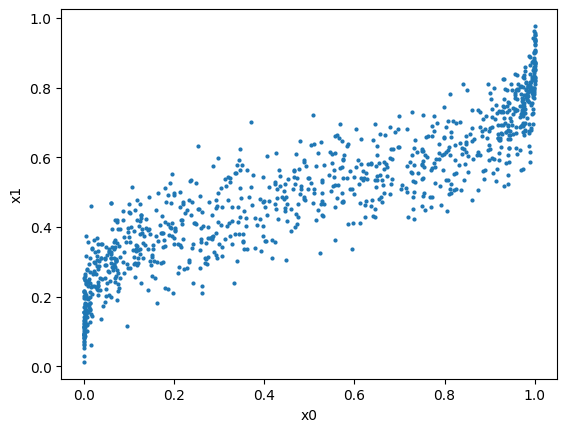

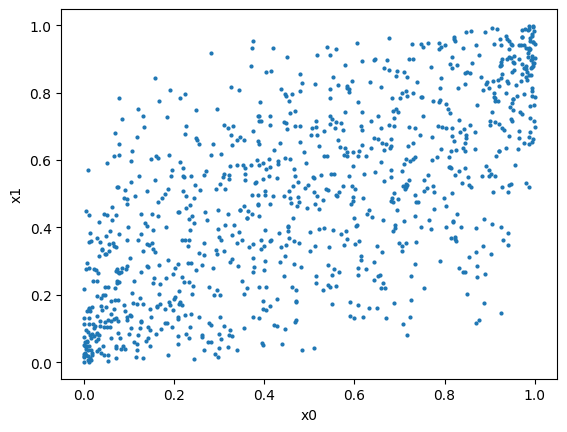

In [20]:
# Distribution object
# dist = torch.distributions.MultivariateNormal(mu, covariance_matrix=Sigma)
def plotMarg(Z,d = 4):
    X_np = Z.detach().cpu().numpy()
    plt.figure()
    plt.scatter(X_np[0,:], X_np[1,:], s=d)
    plt.xlabel("x0")
    plt.ylabel("x1")
    plt.show()
plotMarg(Z[0:2,:])
plotMarg(Z[2:4,:])   
    

In [6]:
### custom 4d distribution, mixture of 3 guassians with different correlation structure -> multimodal and one can tune the connection
weights = torch.tensor([0.4, 0.4,0.2])

# Means (2 components × 4 dimensions)
means = torch.tensor([
    [0., 0., 0., 0.],
    [2., 2., 2., 2.],
    [4., 0., 0., 4.]
])

Sigma1 = torch.tensor([
    [1.0, 0.8, 0.2, 0.0],
    [0.8, 1.0, 0.3, 0.15],
    [0.2, 0.3, 1.0, 0.4],
    [0.0, 0.15, 0.4, 1.0]
])

Sigma2 = torch.tensor([
    [1.0, 0.0, 0.4, 0.3],
    [0.0, 1.0, 0.1, 0.25],
    [0.4, 0.1, 1.0, 0.0],
    [0.3, 0.25, 0.0, 1.0]
])

Sigma3 = torch.tensor([
    [1.0, -0.35, 0.2, 0.6],
    [-0.35, 1.0, -0.1, 0.15],
    [0.2, -0.1, 1.0, 0.0],
    [0.6, 0.15, 0.0, 1.0]
])

# Covariances (3 × 4 × 4)
covs = torch.stack([
    Sigma1,
    Sigma2,
    Sigma3
])

params_true_data = {
        "covs" : covs,
        "means" : means,
        "weights" : weights
        }
# components = MultivariateNormal(loc=params_true_data['means'], covariance_matrix=params_true_data['covs'])
# mixture = MixtureSameFamily(mix, params_true_data['weights'])
# samp_mix = mixture.sample((10000,))
# plotMarg(samp_mix.T[0:2,:])

In [83]:
N      = 1000
params = {
    "d" : 4,
    "Sigma" : torch.tensor([
        [1.0, 0.8, 0.2, 0.0],
        [0.8, 1.0, 0.3, 0.15],
        [0.2, 0.3, 1.0, 0.4],
        [0.0, 0.15, 0.4, 1.0]
    ]),
    "S_1"    : torch.diag(torch.tensor([1.0,1.0])),
    "S_2"    : torch.diag(torch.tensor([1.0,1.0])),
    "loc_1"  : torch.tensor([0.0,0.0]),
    "loc_2"  : torch.tensor([0.0,0.0]),
    "eta_1"  : 1,
    "eta_2"  : 1,
    "L_1"    : torch.tensor([
        [1.0, 0.0],
        [0.8, 1.0],
    ]),
    "L_2"    : torch.tensor([
        [1.0, 0.0],
        [0.6, 1.0],
    ])
}
Z = sampleVectorCopula(params,N)

In [ ]:
# add constraints
def model(params,X):
    N = X.shape[0]
    with pyro.plate("data", N):
        z = pyro.sample("z", dist.Categorical(probs=params['weights']),
                        infer={"enumerate": "parallel"}) 
        pyro.sample("x", dist.MultivariateNormal(params['means'][z], params['covs'][z]),obs = X)

def guide(params,X):
    for name, value in params.items():
        pyro.param(name, value.clone())
    
    U = sample()

# variational approx"
# generate from copula
# use normalizing flow to push forward



svi = SVI(model, guide, Adam({"lr": 1e-2}), loss=Trace_ELBO())

IndentationError: expected an indented block after function definition on line 42 (3645869601.py, line 49)